# Model Exploration: PatchTST + GNN Ensemble

This notebook explores the ML architecture (Milestones 17-18):

1. **Surface Graph** - Build and visualize the volatility surface topology
2. **PatchTST** - Temporal encoding for each surface node
3. **GNN** - Cross-sectional message passing over the surface
4. **Ensemble** - Combined model forward pass and embedding analysis

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from datetime import datetime, timedelta

# Model imports
from src.models import (
    SurfaceGraphConfig,
    build_surface_graph,
    PatchTSTModel,
    PatchTSTModelConfig,
    SurfaceGNN,
    GNNModelConfig,
    PatchTST_GNN_Ensemble,
)

np.random.seed(42)
torch.manual_seed(42)

# Check device
if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

print(f"Using device: {DEVICE}")
print("Model components loaded successfully!")

Using device: mps
Model components loaded successfully!


## 1. Surface Graph Construction

The volatility surface is represented as a graph where:
- **Nodes**: 42 points = 7 delta buckets × 6 tenors
- **Edges**: Connect adjacent delta buckets (horizontal) and adjacent tenors (vertical)
- **Edge attributes**: `[delta_distance, tenor_distance]` for weighted message passing

In [2]:
# Build surface graph with default configuration
graph_config = SurfaceGraphConfig()
graph = build_surface_graph(graph_config)

print("Surface Graph Structure:")
print(f"  Nodes: {graph.num_nodes}")
print(f"  Edges: {graph.edge_index.shape[1]}")
print(f"  Edge attributes shape: {graph.edge_attr.shape}")
print(f"\nDelta buckets: {graph.delta_buckets}")
print(f"Tenor days: {graph.tenors_days}")

Surface Graph Structure:
  Nodes: 42
  Edges: 142
  Edge attributes shape: torch.Size([142, 2])

Delta buckets: ['P10', 'P25', 'P40', 'ATM', 'C40', 'C25', 'C10']
Tenor days: [7, 14, 30, 60, 90, 120]


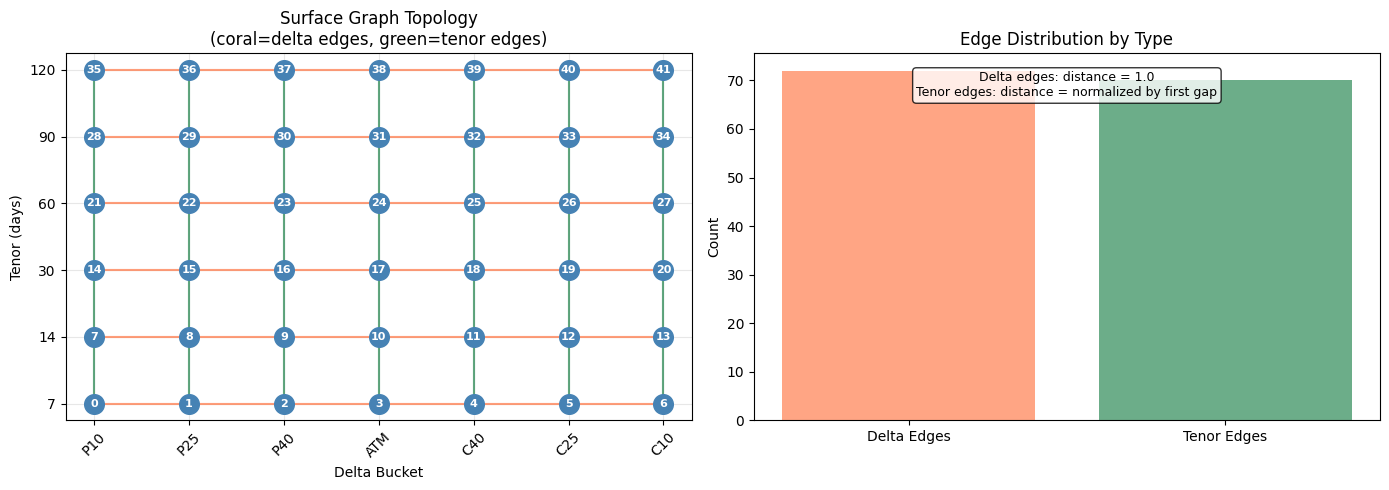


Total edges: 142
Delta adjacency edges: 72 (horizontal connections)
Tenor adjacency edges: 70 (vertical connections)


In [3]:
# Visualize graph topology
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Grid representation
ax = axes[0]
num_deltas = len(graph.delta_buckets)
num_tenors = len(graph.tenors_days)

# Plot nodes as a grid
for t_idx, tenor in enumerate(graph.tenors_days):
    for d_idx, bucket in enumerate(graph.delta_buckets):
        node_idx = graph.node_mapping[(tenor, bucket)]
        ax.scatter(d_idx, t_idx, s=200, c='steelblue', zorder=3)
        ax.annotate(str(node_idx), (d_idx, t_idx), ha='center', va='center', 
                   fontsize=8, color='white', fontweight='bold')

# Plot edges
edge_index = graph.edge_index.numpy()
edge_attr = graph.edge_attr.numpy()

for i in range(edge_index.shape[1]):
    src, dst = edge_index[0, i], edge_index[1, i]
    src_pos = graph.index_mapping[src]
    dst_pos = graph.index_mapping[dst]
    
    src_t = graph.tenors_days.index(src_pos[0])
    src_d = graph.delta_buckets.index(src_pos[1])
    dst_t = graph.tenors_days.index(dst_pos[0])
    dst_d = graph.delta_buckets.index(dst_pos[1])
    
    delta_dist, tenor_dist = edge_attr[i]
    color = 'coral' if delta_dist > 0 else 'seagreen'
    
    ax.plot([src_d, dst_d], [src_t, dst_t], c=color, alpha=0.5, linewidth=1.5)

ax.set_xticks(range(num_deltas))
ax.set_xticklabels(graph.delta_buckets, rotation=45)
ax.set_yticks(range(num_tenors))
ax.set_yticklabels(graph.tenors_days)
ax.set_xlabel('Delta Bucket')
ax.set_ylabel('Tenor (days)')
ax.set_title('Surface Graph Topology\n(coral=delta edges, green=tenor edges)')
ax.grid(True, alpha=0.3)

# Right: Edge attribute distribution
ax = axes[1]
delta_edges = edge_attr[edge_attr[:, 0] > 0]
tenor_edges = edge_attr[edge_attr[:, 1] > 0]

ax.bar(['Delta Edges', 'Tenor Edges'], [len(delta_edges), len(tenor_edges)], 
       color=['coral', 'seagreen'], alpha=0.7)
ax.set_ylabel('Count')
ax.set_title('Edge Distribution by Type')

# Add edge attribute info
info_text = f"Delta edges: distance = 1.0\nTenor edges: distance = normalized by first gap"
ax.text(0.5, 0.95, info_text, transform=ax.transAxes, ha='center', va='top',
        fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"\nTotal edges: {len(edge_attr)}")
print(f"Delta adjacency edges: {len(delta_edges)} (horizontal connections)")
print(f"Tenor adjacency edges: {len(tenor_edges)} (vertical connections)")

## 2. Generate Synthetic Feature Data

Create synthetic time series data matching the expected input format:
- Shape: `(batch, time_steps, num_nodes, num_features)`

In [4]:
# Model dimensions
BATCH_SIZE = 8
TIME_STEPS = 22  # ~1 month of trading days
NUM_NODES = graph.num_nodes  # 42
NUM_FEATURES = 13  # Typical feature count
NUM_HORIZONS = 3   # 5d, 10d, 21d predictions

# Generate synthetic input data
def generate_synthetic_batch(batch_size, time_steps, num_nodes, num_features):
    """Generate synthetic feature tensor with realistic patterns."""
    # Base features with temporal structure (AR(1) process)
    X = torch.zeros(batch_size, time_steps, num_nodes, num_features)
    
    for b in range(batch_size):
        for n in range(num_nodes):
            # Each node has its own AR(1) process
            ar_coef = 0.9
            for f in range(num_features):
                noise = torch.randn(time_steps) * 0.1
                for t in range(1, time_steps):
                    X[b, t, n, f] = ar_coef * X[b, t-1, n, f] + noise[t]
    
    # Add cross-sectional structure (nearby nodes are correlated)
    # This mimics real volatility surface behavior
    for b in range(batch_size):
        for t in range(time_steps):
            # Add spatial smoothing
            node_features = X[b, t, :, :].clone()
            for i in range(graph.edge_index.shape[1]):
                src, dst = graph.edge_index[0, i].item(), graph.edge_index[1, i].item()
                # Small correlation with neighbors
                X[b, t, dst, :] += 0.1 * node_features[src, :]
    
    return X

# Generate data
X = generate_synthetic_batch(BATCH_SIZE, TIME_STEPS, NUM_NODES, NUM_FEATURES)
y = torch.randn(BATCH_SIZE, NUM_NODES, NUM_HORIZONS)  # Random targets
mask = torch.ones(BATCH_SIZE, NUM_NODES, dtype=torch.bool)  # All nodes valid

print(f"Input X shape: {X.shape}")
print(f"  - Batch size: {BATCH_SIZE}")
print(f"  - Time steps: {TIME_STEPS}")
print(f"  - Num nodes: {NUM_NODES}")
print(f"  - Num features: {NUM_FEATURES}")
print(f"\nTarget y shape: {y.shape}")
print(f"Mask shape: {mask.shape}")

Input X shape: torch.Size([8, 22, 42, 13])
  - Batch size: 8
  - Time steps: 22
  - Num nodes: 42
  - Num features: 13

Target y shape: torch.Size([8, 42, 3])
Mask shape: torch.Size([8, 42])


## 3. PatchTST: Temporal Encoding

PatchTST processes each node's time series independently through:
1. **Patching**: Divide time series into overlapping patches
2. **Embedding**: Project patches to d_model dimensions
3. **Transformer**: Self-attention over patches
4. **Pooling**: Mean pool to get per-node embedding

In [5]:
# Initialize PatchTST
patchtst_config = PatchTSTModelConfig(
    patch_len=12,   # Each patch covers 12 time steps
    stride=6,       # 50% overlap between patches
    d_model=128,    # Embedding dimension
    n_heads=8,      # Attention heads
    n_layers=3,     # Transformer layers
    dropout=0.1,
)

# Model for encoding only (no prediction head)
patchtst = PatchTSTModel(
    config=patchtst_config,
    input_dim=NUM_FEATURES,
    output_horizons=0,  # No head - we'll use GNN output
)
patchtst.eval()

print("PatchTST Configuration:")
print(f"  Patch length: {patchtst_config.patch_len}")
print(f"  Stride: {patchtst_config.stride}")
print(f"  d_model: {patchtst_config.d_model}")
print(f"  Attention heads: {patchtst_config.n_heads}")
print(f"  Layers: {patchtst_config.n_layers}")

# Calculate expected number of patches
num_patches = (TIME_STEPS - patchtst_config.patch_len) // patchtst_config.stride + 1
print(f"\nExpected patches per node: {num_patches}")

PatchTST Configuration:
  Patch length: 12
  Stride: 6
  d_model: 128
  Attention heads: 8
  Layers: 3

Expected patches per node: 2


Temporal embeddings shape: torch.Size([8, 42, 128])
  - (batch=8, nodes=42, d_model=128)


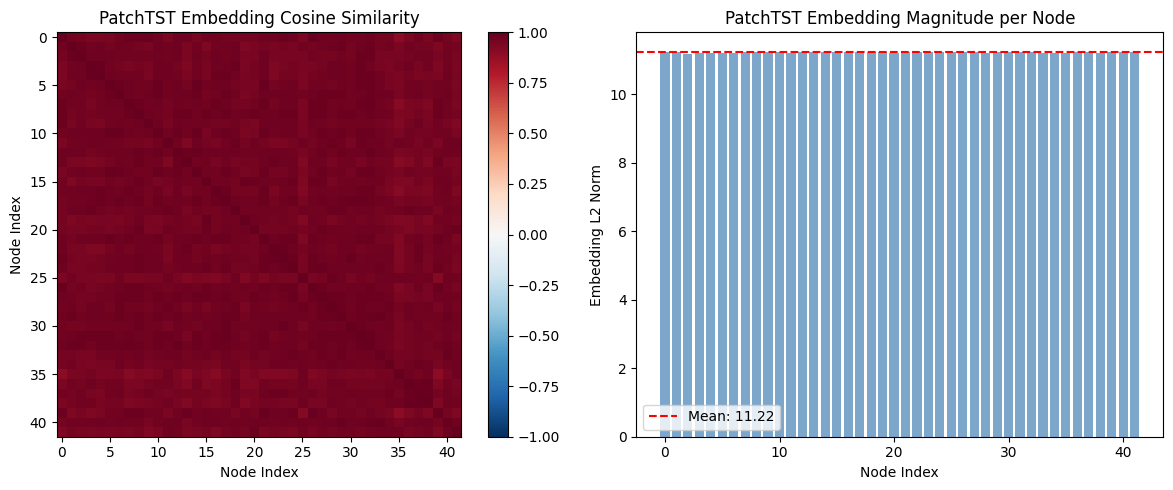

In [6]:
# Run PatchTST encoding
with torch.no_grad():
    temporal_embeddings = patchtst.encode(X)

print(f"Temporal embeddings shape: {temporal_embeddings.shape}")
print(f"  - (batch={BATCH_SIZE}, nodes={NUM_NODES}, d_model={patchtst_config.d_model})")

# Visualize embedding similarity across nodes
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Sample one batch item
sample_emb = temporal_embeddings[0].numpy()  # (nodes, d_model)

# Cosine similarity between nodes
norms = np.linalg.norm(sample_emb, axis=1, keepdims=True)
normalized = sample_emb / (norms + 1e-8)
similarity = normalized @ normalized.T

im = axes[0].imshow(similarity, cmap='RdBu_r', vmin=-1, vmax=1)
axes[0].set_xlabel('Node Index')
axes[0].set_ylabel('Node Index')
axes[0].set_title('PatchTST Embedding Cosine Similarity')
plt.colorbar(im, ax=axes[0])

# Embedding magnitude by node
magnitudes = np.linalg.norm(sample_emb, axis=1)
axes[1].bar(range(NUM_NODES), magnitudes, color='steelblue', alpha=0.7)
axes[1].set_xlabel('Node Index')
axes[1].set_ylabel('Embedding L2 Norm')
axes[1].set_title('PatchTST Embedding Magnitude per Node')
axes[1].axhline(magnitudes.mean(), color='red', linestyle='--', label=f'Mean: {magnitudes.mean():.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. GNN: Cross-Sectional Encoding

The GNN propagates information across the surface graph:
- **GAT (Graph Attention)**: Learns to weight neighbor importance
- **Edge attributes**: delta_distance and tenor_distance inform message passing
- Captures that adjacent delta buckets share skew, adjacent tenors share term structure

In [7]:
# Initialize GNN
gnn_config = GNNModelConfig(
    model_type="GAT",    # Graph Attention Network
    hidden_dim=64,       # Output dimension
    n_layers=2,          # GNN layers
    heads=4,             # Attention heads
    dropout=0.1,
    use_edge_attr=True,  # Use edge attributes
)

gnn = SurfaceGNN(
    config=gnn_config,
    input_dim=patchtst_config.d_model,  # Takes PatchTST output
)
gnn.eval()

print("GNN Configuration:")
print(f"  Model type: {gnn_config.model_type}")
print(f"  Hidden dim: {gnn_config.hidden_dim}")
print(f"  Layers: {gnn_config.n_layers}")
print(f"  Attention heads: {gnn_config.heads}")
print(f"  Edge attributes: {gnn_config.use_edge_attr}")

GNN Configuration:
  Model type: GAT
  Hidden dim: 64
  Layers: 2
  Attention heads: 4
  Edge attributes: True


Graph embeddings shape: torch.Size([8, 42, 64])
  - (batch=8, nodes=42, hidden_dim=64)


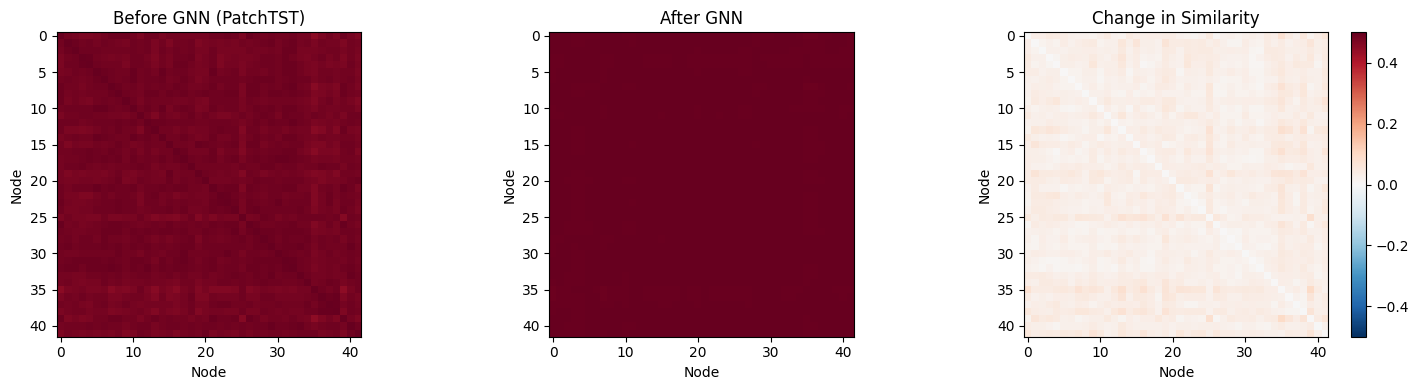

In [8]:
# Run GNN on temporal embeddings
with torch.no_grad():
    graph_embeddings = gnn(temporal_embeddings, graph.edge_index, graph.edge_attr)

print(f"Graph embeddings shape: {graph_embeddings.shape}")
print(f"  - (batch={BATCH_SIZE}, nodes={NUM_NODES}, hidden_dim={gnn_config.hidden_dim})")

# Visualize how GNN changes embeddings
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Before GNN (PatchTST output)
before = temporal_embeddings[0].numpy()
before_norm = before / (np.linalg.norm(before, axis=1, keepdims=True) + 1e-8)
sim_before = before_norm @ before_norm.T

im = axes[0].imshow(sim_before, cmap='RdBu_r', vmin=-1, vmax=1)
axes[0].set_title('Before GNN (PatchTST)')
axes[0].set_xlabel('Node')
axes[0].set_ylabel('Node')

# After GNN
after = graph_embeddings[0].numpy()
after_norm = after / (np.linalg.norm(after, axis=1, keepdims=True) + 1e-8)
sim_after = after_norm @ after_norm.T

im = axes[1].imshow(sim_after, cmap='RdBu_r', vmin=-1, vmax=1)
axes[1].set_title('After GNN')
axes[1].set_xlabel('Node')
axes[1].set_ylabel('Node')

# Difference (what the GNN added)
# Note: dimensions are different, so we compare structure
# Show which nodes became more/less similar
diff = sim_after - np.resize(sim_before, sim_after.shape)[:NUM_NODES, :NUM_NODES]
im = axes[2].imshow(diff, cmap='RdBu_r', vmin=-0.5, vmax=0.5)
axes[2].set_title('Change in Similarity')
axes[2].set_xlabel('Node')
axes[2].set_ylabel('Node')
plt.colorbar(im, ax=axes[2])

plt.tight_layout()
plt.show()

## 5. Full Ensemble Model

The `PatchTST_GNN_Ensemble` combines both components:

```
X: (batch, time, nodes, features)
       ↓
PatchTST.encode(): (batch, nodes, d_model)
       ↓
SurfaceGNN: (batch, nodes, hidden_dim)
       ↓
Linear head: (batch, nodes, horizons)
```

In [9]:
# Initialize ensemble model
ensemble = PatchTST_GNN_Ensemble(
    patchtst_config=patchtst_config,
    gnn_config=gnn_config,
    input_dim=NUM_FEATURES,
    output_horizons=NUM_HORIZONS,
)
ensemble.eval()

# Count parameters
total_params = sum(p.numel() for p in ensemble.parameters())
patchtst_params = sum(p.numel() for p in ensemble.patchtst.parameters())
gnn_params = sum(p.numel() for p in ensemble.gnn.parameters())

print("Ensemble Model Summary:")
print(f"  Total parameters: {total_params:,}")
print(f"  PatchTST parameters: {patchtst_params:,} ({100*patchtst_params/total_params:.1f}%)")
print(f"  GNN parameters: {gnn_params:,} ({100*gnn_params/total_params:.1f}%)")
print(f"  Head parameters: {total_params - patchtst_params - gnn_params:,}")

Ensemble Model Summary:
  Total parameters: 482,371
  PatchTST parameters: 430,336 (89.2%)
  GNN parameters: 51,840 (10.7%)
  Head parameters: 195


Input shape: torch.Size([8, 22, 42, 13])
Output shape: torch.Size([8, 42, 3])
  - Predictions for 3 horizons at 42 nodes


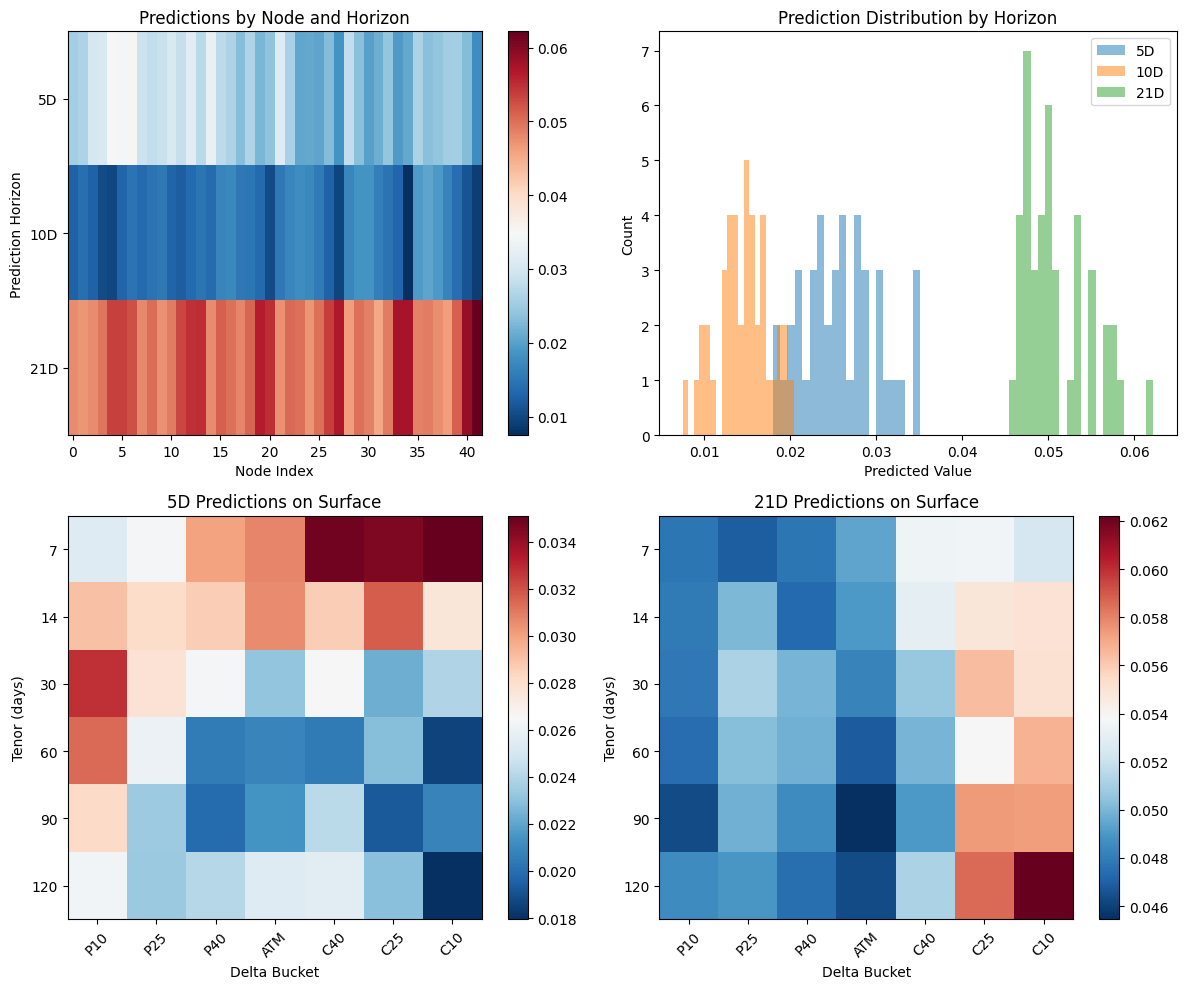

In [10]:
# Forward pass
with torch.no_grad():
    predictions = ensemble(X, graph.edge_index, graph.edge_attr, mask)

print(f"Input shape: {X.shape}")
print(f"Output shape: {predictions.shape}")
print(f"  - Predictions for {NUM_HORIZONS} horizons at {NUM_NODES} nodes")

# Visualize predictions
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Sample predictions by node (one batch item)
sample_preds = predictions[0].numpy()  # (nodes, horizons)

# Heatmap of predictions
im = axes[0, 0].imshow(sample_preds.T, aspect='auto', cmap='RdBu_r')
axes[0, 0].set_xlabel('Node Index')
axes[0, 0].set_yticks([0, 1, 2])
axes[0, 0].set_yticklabels(['5D', '10D', '21D'])
axes[0, 0].set_ylabel('Prediction Horizon')
axes[0, 0].set_title('Predictions by Node and Horizon')
plt.colorbar(im, ax=axes[0, 0])

# Distribution of predictions by horizon
for h, label in enumerate(['5D', '10D', '21D']):
    axes[0, 1].hist(sample_preds[:, h], bins=20, alpha=0.5, label=label)
axes[0, 1].set_xlabel('Predicted Value')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Prediction Distribution by Horizon')
axes[0, 1].legend()

# Reshape predictions to surface grid (one horizon)
def reshape_to_grid(values, graph):
    """Reshape node values to delta x tenor grid."""
    num_deltas = len(graph.delta_buckets)
    num_tenors = len(graph.tenors_days)
    grid = np.zeros((num_tenors, num_deltas))
    
    for node_idx in range(len(values)):
        tenor, bucket = graph.index_mapping[node_idx]
        t_idx = graph.tenors_days.index(tenor)
        d_idx = graph.delta_buckets.index(bucket)
        grid[t_idx, d_idx] = values[node_idx]
    
    return grid

# 5D predictions on surface
grid_5d = reshape_to_grid(sample_preds[:, 0], graph)
im = axes[1, 0].imshow(grid_5d, cmap='RdBu_r', aspect='auto')
axes[1, 0].set_xticks(range(len(graph.delta_buckets)))
axes[1, 0].set_xticklabels(graph.delta_buckets, rotation=45)
axes[1, 0].set_yticks(range(len(graph.tenors_days)))
axes[1, 0].set_yticklabels(graph.tenors_days)
axes[1, 0].set_xlabel('Delta Bucket')
axes[1, 0].set_ylabel('Tenor (days)')
axes[1, 0].set_title('5D Predictions on Surface')
plt.colorbar(im, ax=axes[1, 0])

# 21D predictions on surface
grid_21d = reshape_to_grid(sample_preds[:, 2], graph)
im = axes[1, 1].imshow(grid_21d, cmap='RdBu_r', aspect='auto')
axes[1, 1].set_xticks(range(len(graph.delta_buckets)))
axes[1, 1].set_xticklabels(graph.delta_buckets, rotation=45)
axes[1, 1].set_yticks(range(len(graph.tenors_days)))
axes[1, 1].set_yticklabels(graph.tenors_days)
axes[1, 1].set_xlabel('Delta Bucket')
axes[1, 1].set_ylabel('Tenor (days)')
axes[1, 1].set_title('21D Predictions on Surface')
plt.colorbar(im, ax=axes[1, 1])

plt.tight_layout()
plt.show()

## 6. Embedding Analysis

Let's analyze the learned representations using dimensionality reduction.

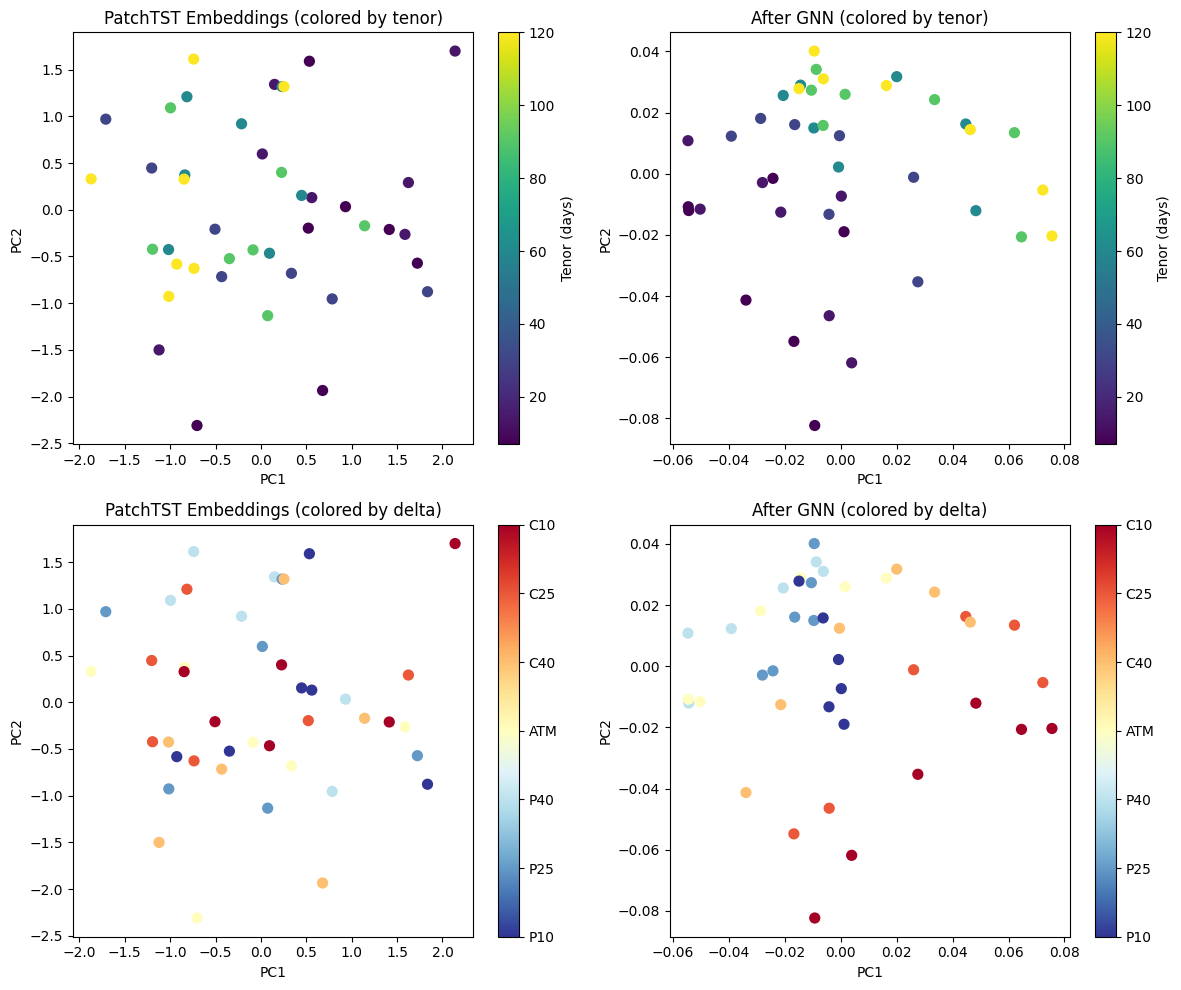


Note: With random weights, embeddings won't show meaningful clustering.
After training, we expect:
  - Nodes with similar tenors to cluster together
  - Nodes with similar deltas to cluster together
  - The GNN to create smoother, more organized embeddings


In [11]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Extract embeddings
with torch.no_grad():
    temporal_emb = ensemble.patchtst.encode(X)
    graph_emb = ensemble.encode(X, graph.edge_index, graph.edge_attr)

# Use first batch item
temp_np = temporal_emb[0].numpy()
graph_np = graph_emb[0].numpy()

# PCA reduction
pca_temp = PCA(n_components=2).fit_transform(temp_np)
pca_graph = PCA(n_components=2).fit_transform(graph_np)

# Create node labels for coloring
node_tenors = [graph.index_mapping[i][0] for i in range(NUM_NODES)]
node_deltas = [graph.delta_buckets.index(graph.index_mapping[i][1]) for i in range(NUM_NODES)]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# PCA by tenor
scatter = axes[0, 0].scatter(pca_temp[:, 0], pca_temp[:, 1], c=node_tenors, cmap='viridis', s=50)
axes[0, 0].set_xlabel('PC1')
axes[0, 0].set_ylabel('PC2')
axes[0, 0].set_title('PatchTST Embeddings (colored by tenor)')
plt.colorbar(scatter, ax=axes[0, 0], label='Tenor (days)')

scatter = axes[0, 1].scatter(pca_graph[:, 0], pca_graph[:, 1], c=node_tenors, cmap='viridis', s=50)
axes[0, 1].set_xlabel('PC1')
axes[0, 1].set_ylabel('PC2')
axes[0, 1].set_title('After GNN (colored by tenor)')
plt.colorbar(scatter, ax=axes[0, 1], label='Tenor (days)')

# PCA by delta bucket
scatter = axes[1, 0].scatter(pca_temp[:, 0], pca_temp[:, 1], c=node_deltas, cmap='RdYlBu_r', s=50)
axes[1, 0].set_xlabel('PC1')
axes[1, 0].set_ylabel('PC2')
axes[1, 0].set_title('PatchTST Embeddings (colored by delta)')
cbar = plt.colorbar(scatter, ax=axes[1, 0])
cbar.set_ticks(range(len(graph.delta_buckets)))
cbar.set_ticklabels(graph.delta_buckets)

scatter = axes[1, 1].scatter(pca_graph[:, 0], pca_graph[:, 1], c=node_deltas, cmap='RdYlBu_r', s=50)
axes[1, 1].set_xlabel('PC1')
axes[1, 1].set_ylabel('PC2')
axes[1, 1].set_title('After GNN (colored by delta)')
cbar = plt.colorbar(scatter, ax=axes[1, 1])
cbar.set_ticks(range(len(graph.delta_buckets)))
cbar.set_ticklabels(graph.delta_buckets)

plt.tight_layout()
plt.show()

print("\nNote: With random weights, embeddings won't show meaningful clustering.")
print("After training, we expect:")
print("  - Nodes with similar tenors to cluster together")
print("  - Nodes with similar deltas to cluster together")
print("  - The GNN to create smoother, more organized embeddings")

## 7. Training Sanity Check

Verify the model can overfit on a small batch (gradient flow works).

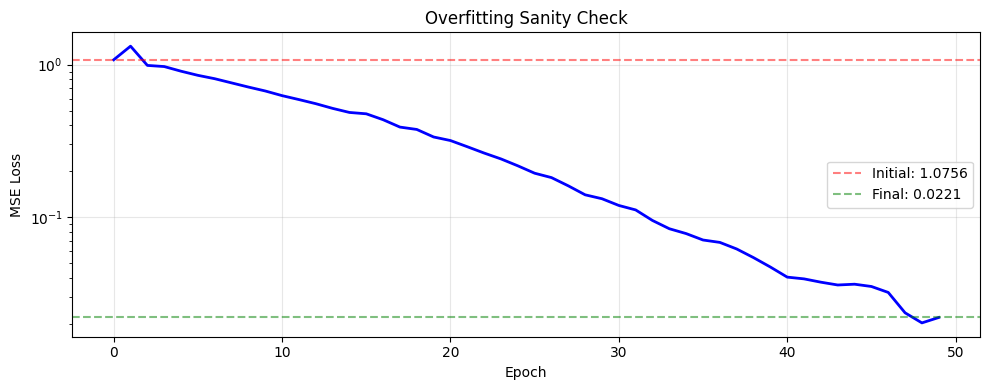


Loss reduced from 1.0756 to 0.0221
Reduction: 97.9%

Status: PASS - Gradients flowing correctly


In [12]:
# Create a fresh model for training test
test_ensemble = PatchTST_GNN_Ensemble(
    patchtst_config=PatchTSTModelConfig(d_model=32, n_layers=1, dropout=0.0),
    gnn_config=GNNModelConfig(hidden_dim=16, n_layers=1, dropout=0.0),
    input_dim=NUM_FEATURES,
    output_horizons=NUM_HORIZONS,
)

# Small batch for overfitting
X_small = torch.randn(4, TIME_STEPS, NUM_NODES, NUM_FEATURES)
y_small = torch.randn(4, NUM_NODES, NUM_HORIZONS)

optimizer = torch.optim.Adam(test_ensemble.parameters(), lr=1e-2)
criterion = nn.MSELoss()

losses = []
test_ensemble.train()

for epoch in range(50):
    optimizer.zero_grad()
    preds = test_ensemble(X_small, graph.edge_index, graph.edge_attr)
    loss = criterion(preds, y_small)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

# Plot loss curve
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(losses, 'b-', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Overfitting Sanity Check')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)

ax.axhline(losses[0], color='red', linestyle='--', alpha=0.5, label=f'Initial: {losses[0]:.4f}')
ax.axhline(losses[-1], color='green', linestyle='--', alpha=0.5, label=f'Final: {losses[-1]:.4f}')
ax.legend()

plt.tight_layout()
plt.show()

reduction = (losses[0] - losses[-1]) / losses[0] * 100
print(f"\nLoss reduced from {losses[0]:.4f} to {losses[-1]:.4f}")
print(f"Reduction: {reduction:.1f}%")
print(f"\nStatus: {'PASS - Gradients flowing correctly' if reduction > 50 else 'WARNING - Check gradient flow'}")

## Summary

This notebook demonstrated the PatchTST + GNN ensemble architecture:

| Component | Input Shape | Output Shape | Purpose |
|-----------|-------------|--------------|--------|
| **Surface Graph** | - | 42 nodes, ~156 edges | Defines surface topology |
| **PatchTST** | (B, T, N, F) | (B, N, d_model) | Temporal encoding per node |
| **SurfaceGNN** | (B, N, d_model) | (B, N, hidden) | Cross-sectional message passing |
| **Ensemble** | (B, T, N, F) | (B, N, H) | End-to-end predictions |

**Key Insights:**
1. PatchTST processes each node independently - learns *how* volatility evolves
2. GNN propagates information across neighbors - learns *where* patterns spread
3. Edge attributes (delta/tenor distance) inform weighted message passing
4. The combination captures both temporal dynamics and surface structure

**Next Steps (M19):**
- Training infrastructure with proper loss functions
- Scheduled learning rate and early stopping
- Validation metrics and model selection

In [13]:
print("=" * 60)
print("MODEL EXPLORATION COMPLETE")
print("=" * 60)
print(f"\nModel Architecture:")
print(f"  PatchTST: {patchtst_config.n_layers} layers, d_model={patchtst_config.d_model}")
print(f"  GNN: {gnn_config.n_layers} layers, hidden={gnn_config.hidden_dim}, type={gnn_config.model_type}")
print(f"  Total params: {total_params:,}")
print(f"\nGraph Structure:")
print(f"  Nodes: {graph.num_nodes} (7 deltas × 6 tenors)")
print(f"  Edges: {graph.edge_index.shape[1]} (bidirectional)")
print(f"\nReady for training (M19)!")

MODEL EXPLORATION COMPLETE

Model Architecture:
  PatchTST: 3 layers, d_model=128
  GNN: 2 layers, hidden=64, type=GAT
  Total params: 482,371

Graph Structure:
  Nodes: 42 (7 deltas × 6 tenors)
  Edges: 142 (bidirectional)

Ready for training (M19)!
